Logistic Regression with multiple variables

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

Load the dataset into a pandas dataframe

we observed that the url to load the data is not working so we download the data and load

In [2]:
df = pd.read_csv('logistic_regression_sample_data.csv')
df.head()

,x1,x2,x3,label
0,-0.332727,-0.696181,-0.286767,0
1,-1.510220,-1.375861,-1.197257,0
2,-1.256076,-1.228764,-1.785996,0
3,-0.772276,-0.409598,-0.267973,0
4,-1.346263,0.112805,0.612268,0


convert columns to numpy arrays

use numpy to stack the 3 x(s) to 1 X

then print

In [3]:
x1 = np.array(df['x1'], dtype=float)
x2 = np.array(df['x2'], dtype=float)
x3 = np.array(df['x3'], dtype=float)
y = np.array(df['label'], dtype=float)

X = np.column_stack((x1, x2, x3))
display(X.shape, y.shape)
X


(200, 3)

(200,)

array([[-3.32727288e-01, -6.96181041e-01, -2.86766581e-01],
       [-1.51022049e+00, -1.37586113e+00, -1.19725687e+00],
       [-1.25607624e+00, -1.22876370e+00, -1.78599642e+00],
       [-7.72276364e-01, -4.09598435e-01, -2.67973078e-01],
       [-1.34626309e+00,  1.12805059e-01,  6.12267555e-01],
       [ 2.15636892e-01,  2.98918001e-01,  1.03272447e+00],
       [ 6.70567936e-01,  1.92308238e-01,  1.64721375e+00],
       [-1.31646482e-01,  6.91599305e-01,  1.59772213e-02],
       [ 2.38841369e-01,  9.04251521e-01,  2.91584612e-01],
       [-6.28618178e-01, -3.27819886e-01, -3.79269256e-02],
       [ 1.20913644e+00,  7.92472643e-01, -4.47009021e-01],
       [ 9.40205968e-01,  1.49413905e+00,  3.53375636e-01],
       [-1.23353761e+00,  6.66406329e-03,  7.03680945e-01],
       [ 1.34774888e-01, -1.51270519e-01, -5.32092286e-01],
       [-3.77867697e-01,  5.61597099e-01,  1.07528066e-01],
       [ 7.44568943e-01,  2.67232902e-01,  9.54881922e-01],
       [-8.67011677e-01, -6.43080237e-01

Plot the value of X and y

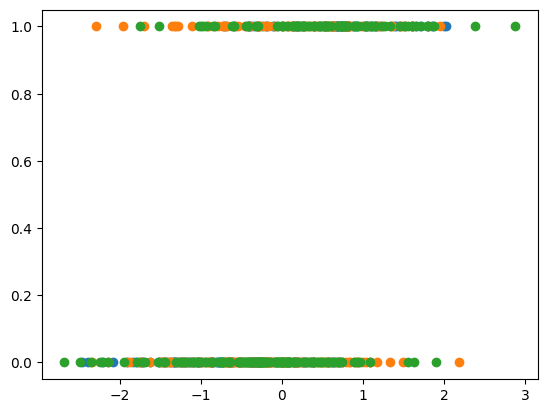

In [4]:
plt.plot(X, y, 'o')
plt.show()

We now create the linear function will will be passed into the logistic function (we creating that also)

In [5]:
def linear(m1, m2, m3, m0, x1, x2, x3):
    return (m1 * x1) + (m2 * x2) + (m3 * x3) + m0

In [6]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

let us test our functions

In [7]:
m0, m1, m2, m3 = 0.5, 0.5, 0.5, 0.5

In [8]:
y_pred = sigmoid(linear(m1, m2, m3, m0, X[:, 0], X[:, 1], X[:, 2]))
y_pred

array([0.46062235, 0.17629275, 0.16308948, 0.44400489, 0.54721014,
       0.78136516, 0.85258799, 0.68739421, 0.77159488, 0.50070438,
       0.78198983, 0.86919506, 0.55932023, 0.55618818, 0.65602473,
       0.81507682, 0.51761995, 0.73757584, 0.28777663, 0.71482985,
       0.75677153, 0.89137193, 0.64198435, 0.79811552, 0.62186868,
       0.35276865, 0.60029815, 0.49803772, 0.83223503, 0.51811021,
       0.58598434, 0.717411  , 0.5246317 , 0.69706509, 0.72533486,
       0.48234429, 0.53421228, 0.63610841, 0.67980407, 0.8866257 ,
       0.36983   , 0.91624826, 0.86281631, 0.76870269, 0.87085671,
       0.17224604, 0.36138583, 0.22689605, 0.53165608, 0.90601332,
       0.53787556, 0.54408162, 0.11689864, 0.41157212, 0.26274936,
       0.48786595, 0.69691858, 0.83187409, 0.52888056, 0.19477596,
       0.41679096, 0.46587333, 0.46458371, 0.92741686, 0.55835536,
       0.499697  , 0.60915269, 0.43549369, 0.91437207, 0.46005429,
       0.43171898, 0.41061739, 0.82286004, 0.58293762, 0.40148

let us create our cost function also

In [9]:
def cost(y, y_pred):
    return -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))

now we will run a for loop to train a model using gradient decent

we will get the gradients for each parameter and update them

we will continue this process to reduce the error to its minimal

In [10]:
# Initialize training parameters and hyperparameters
m0, m1, m2, m3 = 0, 0, 0, 0
alpha = 0.001
epochs = 1500000
costs = []

In [ ]:
start = time.time()

for i in range(epochs):
    # Predictions, cost and gradient for each data point.
    y_pred = sigmoid(linear(m1, m2, m3, m0, X[:, 0], X[:, 1], X[:, 2]))
    #cost = cost(y, y_pred)
    cost = -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
    costs.append(cost)

    raw_residual = y_pred - y
    dm0 = np.mean(raw_residual)
    dm1 = np.mean(raw_residual * X[:, 0])
    dm2 = np.mean(raw_residual * X[:, 1])
    dm3 = np.mean(raw_residual * X[:, 2])

    # Parameter updates.
    m0 = m0 - alpha * dm0
    m1 = m1 - alpha * dm1
    m2 = m2 - alpha * dm2
    m3 = m3 - alpha * dm3


    print(f"Epoch: {i}, Cost: {cost}")

end = time.time()



Streaming output truncated to the last 5000 lines.
Epoch: 46746, Cost: 0.2506801151329583
Epoch: 46747, Cost: 0.250678120627288
Epoch: 46748, Cost: 0.25067612617635865
Epoch: 46749, Cost: 0.25067413178016795
Epoch: 46750, Cost: 0.25067213743871336
Epoch: 46751, Cost: 0.2506701431519925
Epoch: 46752, Cost: 0.25066814892000294
Epoch: 46753, Cost: 0.2506661547427423
Epoch: 46754, Cost: 0.25066416062020813
Epoch: 46755, Cost: 0.25066216655239804
Epoch: 46756, Cost: 0.2506601725393096
Epoch: 46757, Cost: 0.2506581785809404
Epoch: 46758, Cost: 0.250656184677288
Epoch: 46759, Cost: 0.25065419082835
Epoch: 46760, Cost: 0.25065219703412395
Epoch: 46761, Cost: 0.2506502032946075
Epoch: 46762, Cost: 0.25064820960979817
Epoch: 46763, Cost: 0.2506462159796936
Epoch: 46764, Cost: 0.25064422240429135
Epoch: 46765, Cost: 0.250642228883589
Epoch: 46766, Cost: 0.25064023541758407
Epoch: 46767, Cost: 0.25063824200627427
Epoch: 46768, Cost: 0.25063624864965717
Epoch: 46769, Cost: 0.25063425534773026
Epoch

In [ ]:
print(f"Time taken: {end - start} seconds")

We print our parameters and gradient

then we visualize our cost and prediction against actual target

In [ ]:
# Print gradients.
print('cost:', cost, '\ndm0:', dm0, '\ndm1:', dm1, '\ndm2:', dm2, '\ndm3:', dm3)
plt.figure(figsize=(10, 3))
plt.subplot(1,2,1)
plt.plot(y, y_pred, 'o')

plt.subplot(1,2,2)
plt.plot(costs)